In [1]:
import sys
import os

print("--- Path Analysis and Memory Purge ---")

# --- Step 1: Fix the Search Path ---
incorrect_path = '/home/lwan/.local/lib/python3.10/site-packages'
if incorrect_path in sys.path:
    print(f"Found and removed incorrect path: {incorrect_path}")
    while incorrect_path in sys.path:
        sys.path.remove(incorrect_path)
else:
    print("Incorrect path not found in search path.")

# --- Step 2: Purge All NumPy Modules from Memory ---
# This is the crucial new part. We remove not just 'numpy', but all of its submodules.
numpy_modules = []
for module in sys.modules:
    if module == 'numpy' or module.startswith('numpy.'):
        numpy_modules.append(module)

if numpy_modules:
    print(f"Found and purged {len(numpy_modules)} cached NumPy modules.")
    for module in numpy_modules:
        del sys.modules[module]
else:
    print("No cached NumPy modules found to purge.")

# --- Step 3: Verification ---
try:
    import numpy
    print("\n--- Verification Complete ---")
    print(f"Current NumPy Version: {numpy.__version__}")
    print(f"Current NumPy Location: {numpy.__file__}")

    correct_path_prefix = '/exp/dune/data/users/ayankele/transformercvn_env'
    if correct_path_prefix in numpy.__file__:
        print("\n✅ Success! The kernel is now using the correct NumPy.")
    else:
        print("\n❌ Error! The kernel is still using an incorrect NumPy.")

except ImportError as e:
    print(f"\n❌ An ImportError occurred after cleaning: {e}")

# os.environ["CUDA_VISIBLE_DEVICES"] = ""

--- Path Analysis and Memory Purge ---
Found and removed incorrect path: /home/lwan/.local/lib/python3.10/site-packages
No cached NumPy modules found to purge.

--- Verification Complete ---
Current NumPy Version: 1.23.5
Current NumPy Location: /exp/dune/data/users/ayankele/transformercvn_env/lib/python3.10/site-packages/numpy/__init__.py

✅ Success! The kernel is now using the correct NumPy.


In [2]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
torch.jit.script = lambda x: x

import re 
import h5py
from glob import glob
from functools import partial
from tqdm import tqdm

from tensorflow.python.summary.summary_iterator import summary_iterator

from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from scipy.spatial.distance import pdist, cdist
from scipy import stats

from transformercvn.network.trainers.neutrino_full_dense_trainer import NeutrinoFullDenseTrainer, sparse_to_dense
from transformercvn.network.trainers.neutrino_full_sparse_trainer import NeutrinoFullSparseTrainer
from transformercvn.network.trainers.neutrino_full_sdxl_trainer import NeutrinoFullSDXLTrainer
from transformercvn.dataset.minkowski_dataset import MinkowskiCollection
from transformercvn.options import Options

from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmasher as cmr
import seaborn as sb

2026-01-28 17:33:02.331659: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-28 17:33:02.342117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-28 17:33:02.357479: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-28 17:33:02.362085: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-28 17:33:02.377849: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instru

# Training History

In [3]:
tags = ['lr-AdamW/pg1',  # Learning Rate
        'val_epoch_accuracy', 'event_epoch_accuracy', 'prong_epoch_accuracy', # Validation accuracy, val = (event + prong)/2
        'train_loss', 'train_event_accuracy', 'train_prong_accuracy', # Possibly not helpful with small batch size
        'val_epoch_AUC', 'event_epoch_AUC', 'prong_epoch_AUC'] # ROC AUC, average='weighted'

In [4]:
# If training was stopped and restarted many times, this list can contain many tensorboards
tensorboards = ["./test/version_3/events.out.tfevents.1761920337.jupyter-lwan.165719.0"]

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


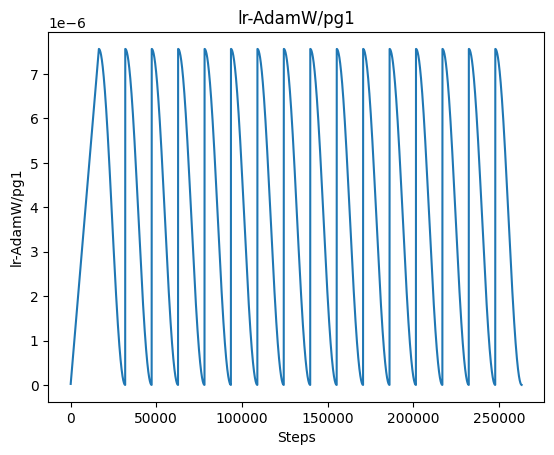

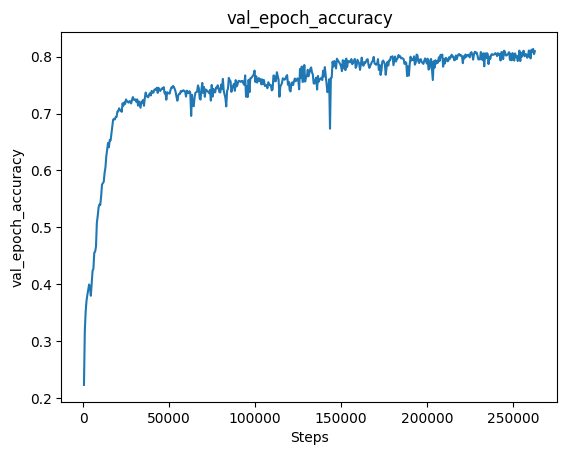

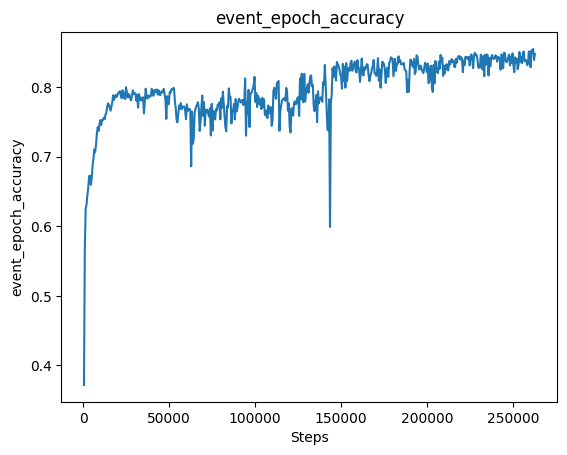

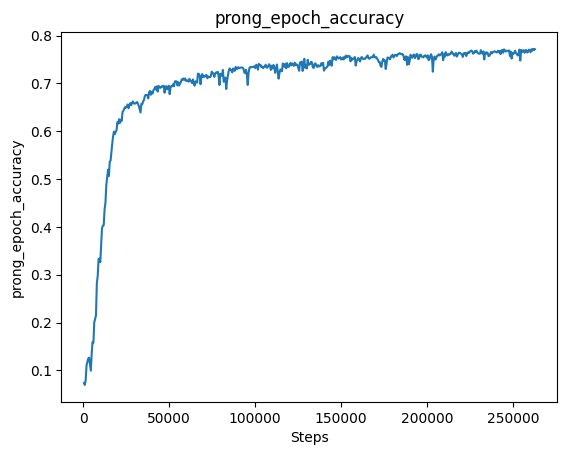

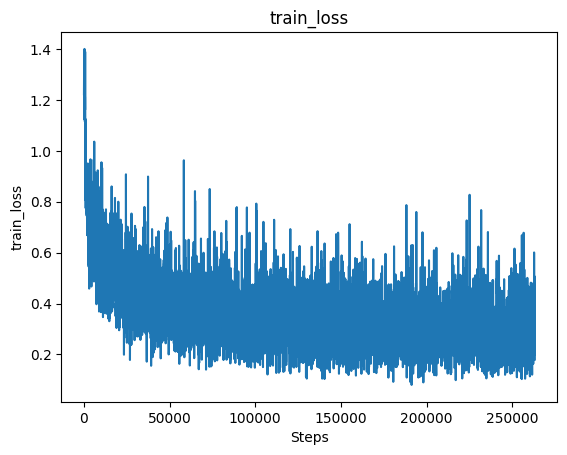

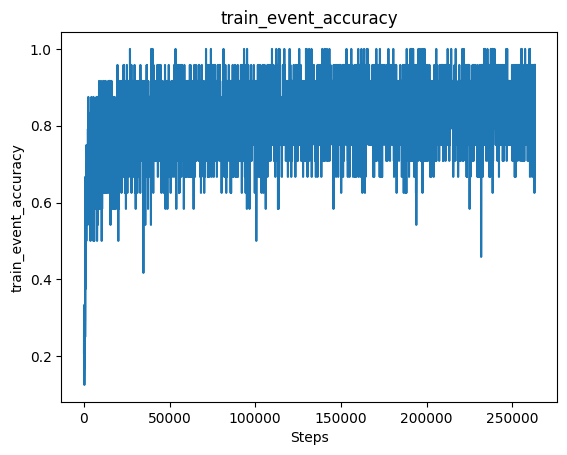

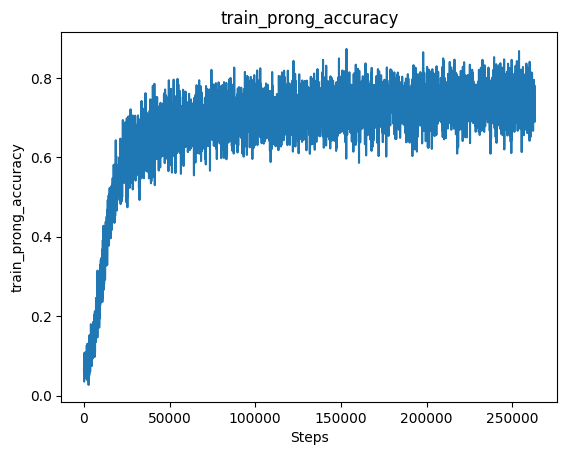

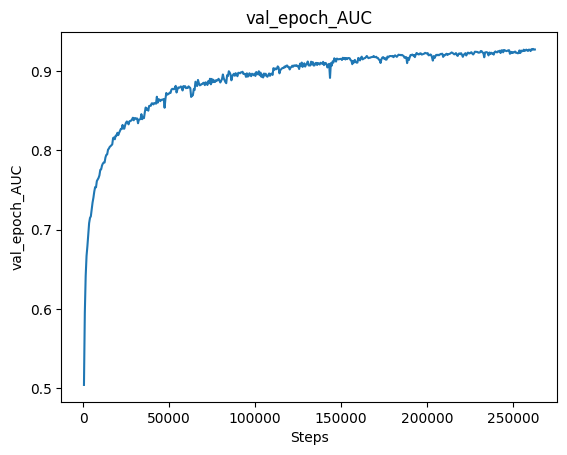

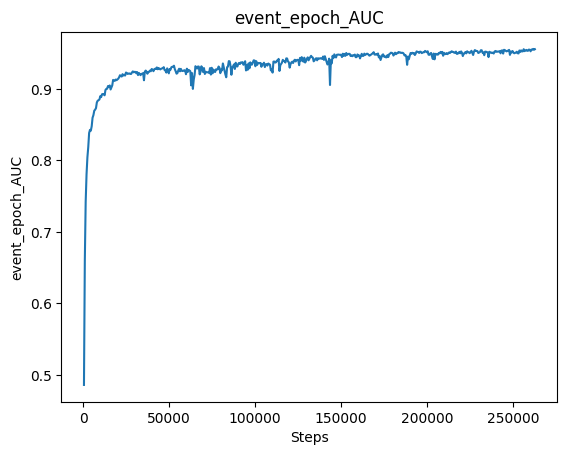

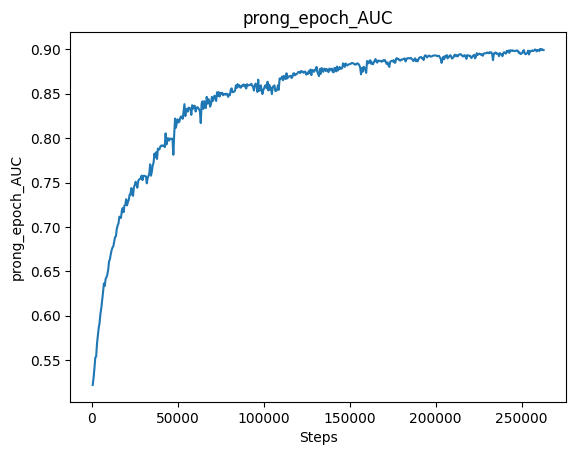

In [5]:
metrics = {tag:[] for tag in tags}

for tensorboard in tensorboards:
  for e in summary_iterator(tensorboard):
    for v in e.summary.value:
      #print(v)
      if v.tag in tags:
        metrics[v.tag].append([e.step, v.simple_value])
        last_step = e.step

for tag in tags:
    metric = np.array(metrics[tag])
    if metric.size==0:
        print("No values saved for metric", tag)
        continue
    plt.plot(metric[:,0], metric[:,1], label=tag)
    plt.xlabel('Steps')
    plt.ylabel(tag)
    plt.title(tag)
    #plt.legend()
    plt.show()

# Testing Dataset

In [6]:
CUDA = True
CUDA_DEVICE = 0
USE_TEX = False
TESTING_FILE = None

TESTING_SOURCE= "validation"
GRADIENT = False

NETWORK = NeutrinoFullDenseTrainer
#NETWORK = NeutrinoFullDenseTrainer
#NETWORK = NeutrinoFullSDXLTrainer

In [7]:
TESTING_FILE = "/exp/dune/data/users/linyan/nnbar/h5/combined/500katm_50k6/atm_nnbar_combined_2M100k6.h5"
#TESTING_FILE = "/exp/dune/data/users/linyan/detsum/Sparse/test.h5"
BASE_DIRECTORY = "./test/version_3/"
#CHECKPOINT_PATH = "./tutorial_dense/version_0/checkpoints/last.ckpt"
CHECKPOINT_PATH = "./test/version_3/checkpoints/last.ckpt"

In [8]:
options = Options.load(f"{BASE_DIRECTORY}/options.json")
if TESTING_FILE:
    options.testing_file = TESTING_FILE
else:
    options.testing_file = options.training_file.replace("training", TESTING_SOURCE)
options.num_dataloader_workers = 0
print(f"Testing file: {TESTING_FILE} {options.testing_file}")

if CHECKPOINT_PATH is None:
    checkpoints = glob(f"{BASE_DIRECTORY}/checkpoints/epoch*.ckpt")
    last_checkpoint = np.argmax([int(re.search("step=(.*).ckpt", s)[1]) for s in checkpoints])
    checkpoint_path = checkpoints[last_checkpoint]
else:
    checkpoint_path = CHECKPOINT_PATH
checkpoint = torch.load(checkpoint_path, map_location='cpu')
state_dict = checkpoint["state_dict"]
print(f"Loading from: {checkpoint_path}")

network = NETWORK(options)
network.load_state_dict(state_dict)

network = network.eval()

if not GRADIENT:
    for parameter in network.parameters():
        parameter.requires_grad_(False)

if CUDA:
    network = network.cuda(CUDA_DEVICE)

Testing file: /exp/dune/data/users/linyan/nnbar/h5/combined/500katm_50k6/atm_nnbar_combined_2M100k6.h5 /exp/dune/data/users/linyan/nnbar/h5/combined/500katm_50k6/atm_nnbar_combined_2M100k6.h5
Loading from: ./test/version_3/checkpoints/last.ckpt


In [9]:
#DATASET = network.training_dataset
#DATASET = network.validation_dataset
DATASET = network.testing_dataset

In [10]:
np.bincount(DATASET.event_targets)

array([ 54543,  63158,  66254, 254878])

In [11]:
dataloader_options = network.dataloader_options
dataloader_options["pin_memory"] = False
dataloader_options["num_workers"] = 0
dataloader_options["batch_size"] = 16
dataloader_options["drop_last"] = False

test_dataloader = network.dataloader(DATASET, **dataloader_options)

In [12]:
batch = next(iter(network.dataloader(DATASET, **dataloader_options)))

if CUDA:
    batch = [b.cuda(CUDA_DEVICE) for b in batch]

(
        features,
        extra,
        event_coordinates,
        event_pixel_values,
        event_masks,
        prong_coordinates,
        prong_pixel_values,
        prong_masks,
        event_target,
        prong_target
) = batch

event_logits, prong_logits = network.forward(
        features,
        extra,
        event_coordinates,
        event_pixel_values,
        event_masks,
        prong_coordinates,
        prong_pixel_values,
        prong_masks,
    )

In [13]:
event_predictions = []
prong_predictions = []

event_targets = []
prong_targets = []

event_raws = []
prong_raws = []

total_attentions = []

for batch_idx, batch in enumerate(tqdm(test_dataloader)):
    if CUDA:
        batch = [b.cuda(CUDA_DEVICE) for b in batch]
        
    (
            features,
            extra,
            event_coordinates,
            event_pixel_values,
            event_masks,
            prong_coordinates,
            prong_pixel_values,
            prong_masks,
            event_target,
            prong_target
    ) = batch
    
    event_logits, prong_logits = network.forward(
            features,
            extra,
            event_coordinates,
            event_pixel_values,
            event_masks,
            prong_coordinates,
            prong_pixel_values,
            prong_masks,
        )
    
    event_predictions.append(event_logits.argmax(-1).cpu())
    prong_predictions.append(prong_logits.argmax(-1).cpu())
    
    event_targets.append(event_target.cpu())
    prong_targets.append(prong_target.cpu())
    
    event_raws.append(event_logits.cpu())
    prong_raws.append(prong_logits.cpu())
            
event_targets = torch.cat(event_targets)
prong_targets = torch.cat(prong_targets)

event_predictions = torch.cat(event_predictions)
prong_predictions = torch.cat(prong_predictions)

event_raws = torch.cat(event_raws)
prong_raws = torch.cat(prong_raws)

prong_mask = prong_targets >= 0

100%|██████████| 27428/27428 [53:24<00:00,  8.56it/s] 


In [14]:
event_probabilities = torch.softmax(event_raws, dim=1)
prong_probabilities = torch.softmax(prong_raws, dim=2)

In [15]:
flat_prong_probabilities = prong_probabilities[prong_mask]
flat_prong_predictions = prong_predictions[prong_mask]
flat_prong_targets = prong_targets[prong_mask]

In [16]:
event_probabilities # Score for [NumuCC, NueCC, NC, Other]

tensor([[0.1404, 0.0163, 0.0047, 0.8386],
        [0.0494, 0.0066, 0.1397, 0.8043],
        [0.0565, 0.0157, 0.0022, 0.9256],
        ...,
        [0.2894, 0.0091, 0.6896, 0.0120],
        [0.1409, 0.8523, 0.0041, 0.0026],
        [0.2495, 0.7420, 0.0030, 0.0055]])

In [17]:
event_targets

tensor([3, 3, 3,  ..., 2, 1, 1], dtype=torch.int32)

In [18]:
prong_probabilities # Score for [Electron, Muon, Proton, Neutron,
                    #            Pi +/-, Pi0, Photon, Other]

tensor([[[5.3025e-03, 4.5452e-02, 9.8642e-02,  ..., 1.6119e-02,
          9.0730e-04, 2.6104e-03],
         [6.8575e-03, 4.1813e-02, 7.0760e-02,  ..., 4.1179e-02,
          1.4611e-03, 2.5259e-03],
         [6.7651e-03, 6.1198e-03, 7.9586e-01,  ..., 1.9823e-02,
          1.0041e-03, 7.8435e-03],
         ...,
         [1.7710e-01, 1.3258e-01, 1.8183e-01,  ..., 1.0397e-01,
          8.4502e-02, 1.1274e-01],
         [1.7710e-01, 1.3258e-01, 1.8183e-01,  ..., 1.0397e-01,
          8.4502e-02, 1.1274e-01],
         [1.7710e-01, 1.3258e-01, 1.8183e-01,  ..., 1.0397e-01,
          8.4502e-02, 1.1274e-01]],

        [[1.9793e-01, 2.5181e-03, 2.3092e-03,  ..., 7.5573e-01,
          3.1381e-02, 5.3849e-04],
         [4.8171e-03, 1.5973e-02, 5.8776e-01,  ..., 1.2166e-02,
          7.4169e-04, 5.6694e-03],
         [1.3007e-02, 5.3509e-03, 8.3573e-01,  ..., 3.8324e-02,
          1.7372e-03, 7.3585e-03],
         ...,
         [1.7710e-01, 1.3258e-01, 1.8183e-01,  ..., 1.0397e-01,
          8.450

In [19]:
prong_targets

tensor([[ 4,  4,  2,  ..., -1, -1, -1],
        [ 5,  2,  2,  ..., -1, -1, -1],
        [ 4,  2,  2,  ..., -1, -1, -1],
        ...,
        [ 0,  2,  0,  ..., -1, -1, -1],
        [ 1,  1,  2,  ..., -1, -1, -1],
        [ 1,  2,  2,  ..., -1, -1, -1]], dtype=torch.int8)

In [20]:
with h5py.File(BASE_DIRECTORY+"eval_predictions.h5", "w") as file:
    file.create_dataset("event_probabilities", data=event_probabilities.numpy())
    file.create_dataset("event_predictions", data=event_predictions.numpy())
    file.create_dataset("event_targets", data=event_predictions.numpy())
    
    file.create_dataset("prong_probabilities", data=prong_probabilities.numpy())
    file.create_dataset("prong_predictions", data=prong_predictions.numpy())
    file.create_dataset("prong_targets", data=prong_targets.numpy())

# Testing Metrics

In [21]:
event_classes = ["Other", "NumuCC", "NueCC", "NNbar"]
prong_classes = ["Electron", "Muon", "Proton", "Neutron", "Pi+/-", "Pi0", "Photon", "Other"]

In [22]:
print("Event Target Shape: ", event_targets.shape)
print("Event Probability Shape: ", event_probabilities.shape)
print("Prong Target Shape: ", flat_prong_targets.shape)
print("Prong Probability Shape: ", flat_prong_probabilities.shape)

print()

print(f"Event Accuracy: {accuracy_score(event_targets, event_predictions):.3f}")
print(f"Event Precision: {precision_score(event_targets, event_predictions, average='weighted'):.3f}")
print(f"Event Recall: {recall_score(event_targets, event_predictions, average='weighted'):.3f}")
# --- DEBUGGING CODE ---
print(f"Unique classes found in this batch of event_targets: {np.unique(event_targets)}")
print(f"Number of classes defined: {len(event_classes)}")
# --- DEBUGGING CODE ---
print(f"Event ROC AUC: {roc_auc_score(event_targets, event_probabilities, multi_class='ovr', average='weighted'):.3f}")

print(f"Prong Accuracy: {accuracy_score(flat_prong_targets, flat_prong_predictions):.3f}")
print(f"Prong Precision: {precision_score(flat_prong_targets, flat_prong_predictions, average='weighted'):.3f}")
print(f"Prong Recall: {recall_score(flat_prong_targets, flat_prong_predictions, average='weighted'):.3f}")
print(f"Prong ROC AUC: {roc_auc_score(flat_prong_targets, flat_prong_probabilities, multi_class='ovr', average='weighted'):.3f}")

Event Target Shape:  torch.Size([438833])
Event Probability Shape:  torch.Size([438833, 4])
Prong Target Shape:  torch.Size([2426309])
Prong Probability Shape:  torch.Size([2426309, 8])

Event Accuracy: 0.859
Event Precision: 0.869
Event Recall: 0.859
Unique classes found in this batch of event_targets: [0 1 2 3]
Number of classes defined: 4
Event ROC AUC: 0.973
Prong Accuracy: 0.773


/exp/dune/data/users/ayankele/transformercvn_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Prong Precision: 0.763
Prong Recall: 0.773
Prong ROC AUC: 0.938


In [23]:
# Check event classification performance
event_aucs = roc_auc_score(
    event_targets.numpy(),
    event_probabilities.numpy(),
    average=None,
    multi_class="ovr"
)

print(f"Other ROC AUC: {event_aucs[0]:.3f}")
print(f"NumuCC ROC AUC: {event_aucs[1]:.3f}")
print(f"NueCC ROC AUC: {event_aucs[2]:.3f}")
print(f"NNbar AUC: {event_aucs[3]:.3f}")

Other ROC AUC: 0.919
NumuCC ROC AUC: 0.972
NueCC ROC AUC: 0.969
NNbar AUC: 0.986


In [24]:
# Check prong classification performance
prong_aucs = roc_auc_score(
    flat_prong_targets.numpy(),
    flat_prong_probabilities.numpy(),
    average=None,
    multi_class="ovr"
)

print(f"Electron ROC AUC: {prong_aucs[0]:.3f}")
print(f"Muon ROC AUC: {prong_aucs[1]:.3f}")
print(f"Proton ROC AUC: {prong_aucs[2]:.3f}")
print(f"Neutron AUC: {prong_aucs[3]:.3f}")
print(f"Charged Pion ROC AUC: {prong_aucs[4]:.3f}")
print(f"Neutral Pion ROC AUC: {prong_aucs[5]:.3f}")
print(f"Photon ROC AUC: {prong_aucs[6]:.3f}")
print(f"Other AUC: {prong_aucs[7]:.3f}")

Electron ROC AUC: 0.921
Muon ROC AUC: 0.953
Proton ROC AUC: 0.957
Neutron AUC: 0.947
Charged Pion ROC AUC: 0.903
Neutral Pion ROC AUC: 0.947
Photon ROC AUC: 0.840
Other AUC: 0.739


At the closest point to the target FPR of 0.05%:
  - Actual FPR on curve is: 0.0541%
  - Corresponding TPR is:   5.6414%
At the closest point to the target FPR of 0.05%:
  - Actual FPR on curve is: 0.0540%
  - Corresponding TPR is:   21.0108%
At the closest point to the target FPR of 0.05%:
  - Actual FPR on curve is: 0.0542%
  - Corresponding TPR is:   17.2307%
At the closest point to the target FPR of 0.05%:
  - Actual FPR on curve is: 0.0544%
  - Corresponding TPR is:   17.6963%


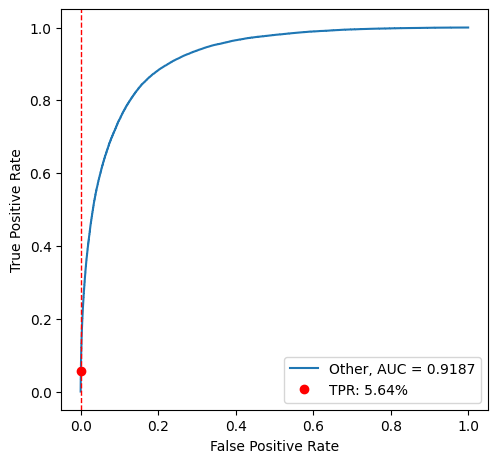

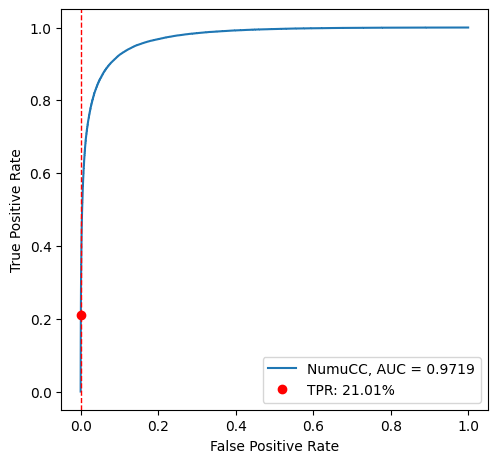

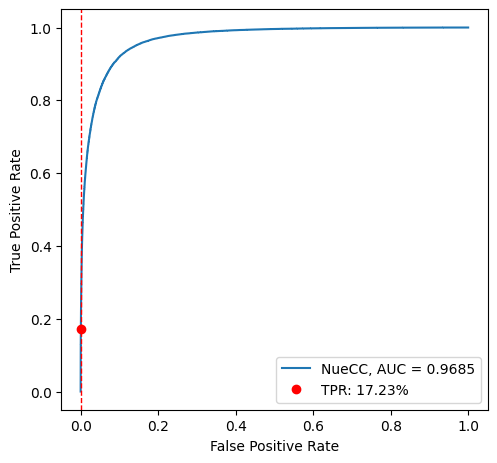

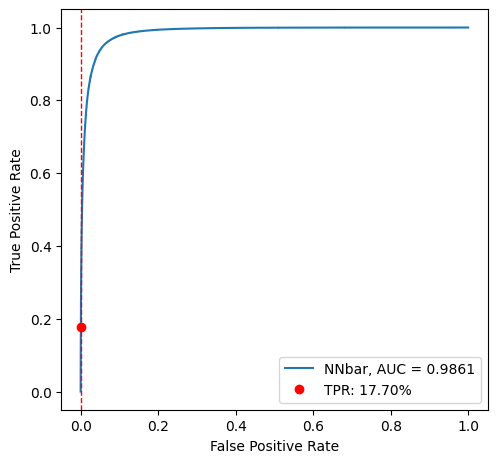

In [25]:
for i in range(4):
    plt.figure(figsize=[5.5,5.2])
    fpr,tpr,thr = roc_curve(event_targets, event_probabilities[:,i], pos_label=i, drop_intermediate=False)
    plt.plot(fpr,tpr, label = "%s, AUC = %.4f" % (event_classes[i],event_aucs[i]))

    target_fpr = 0.00054  # This is 0.02% with 36.8% precut eff
    plt.axvline(x=target_fpr, color='r', linestyle='--', linewidth=1)
    idx = np.searchsorted(fpr, target_fpr)
    tpr_at_target_fpr = tpr[idx]
    actual_fpr = fpr[idx]
    plt.plot(actual_fpr, tpr_at_target_fpr, 'ro', label=f'TPR: {tpr_at_target_fpr:.2%}') # 'ro' = red circle
    print(f"At the closest point to the target FPR of {target_fpr:.2%}:")
    print(f"  - Actual FPR on curve is: {actual_fpr:.4%}")
    print(f"  - Corresponding TPR is:   {tpr_at_target_fpr:.4%}")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')

[Other vs NumuCC] At target FPR 0.05%:
  - Actual FPR on curve: 0.0550%
  - Corresponding TPR : 5.3279%
[NumuCC vs NueCC] At target FPR 0.05%:
  - Actual FPR on curve: 0.0554%
  - Corresponding TPR : 18.1348%
[NueCC vs NNbar] At target FPR 0.05%:
  - Actual FPR on curve: 0.0543%
  - Corresponding TPR : 23.3076%
[NNbar vs Other] At target FPR 0.05%:
  - Actual FPR on curve: 0.0541%
  - Corresponding TPR : 10.9712%


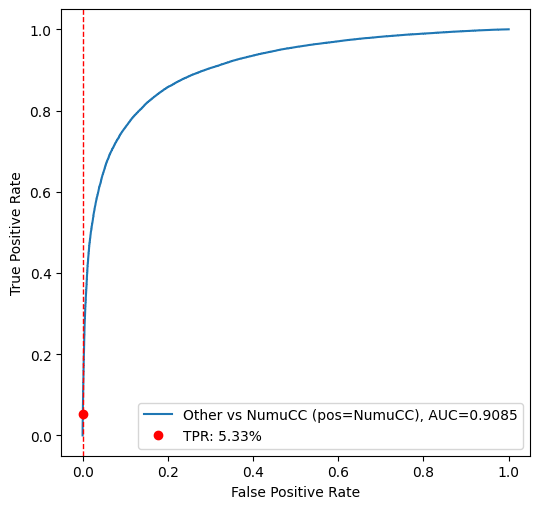

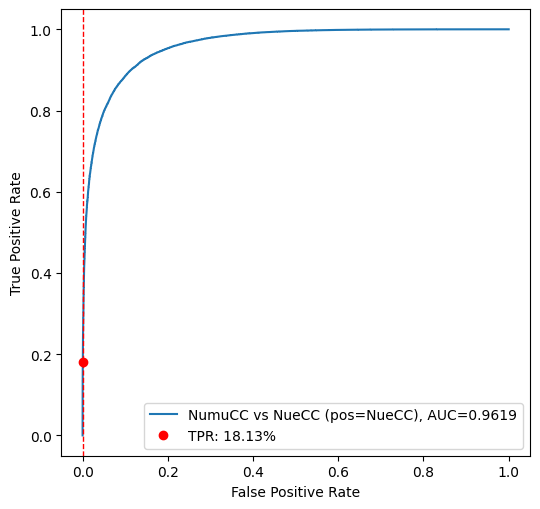

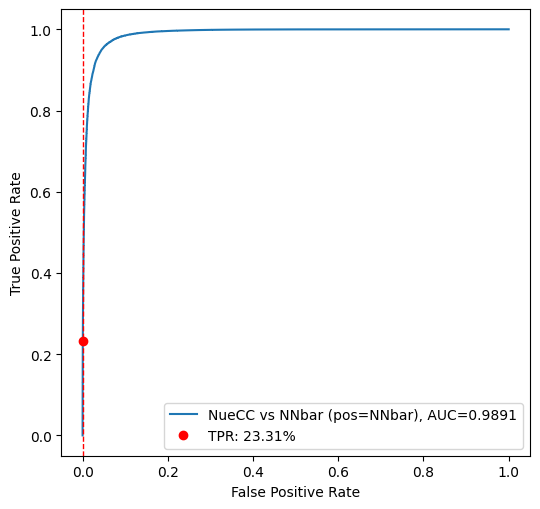

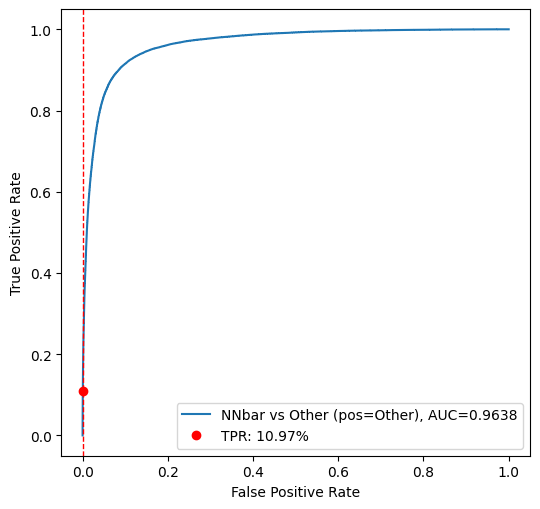

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

def to_numpy(x):
    try:
        import torch
        if torch.is_tensor(x):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

n_classes = event_probabilities.shape[1]

# Convert once
targets_np = to_numpy(event_targets)
probs_np   = to_numpy(event_probabilities)

for i in range(n_classes):
    j = (i + 1) % n_classes  # next class in a ring

    # keep only samples that are either class i or j
    mask = (targets_np == i) | (targets_np == j)
    y_true = (targets_np[mask] == j).astype(int)     # 1 for class j, 0 for class i
    y_score = probs_np[mask, j]                      # score = P(class j)

    fpr, tpr, thr = roc_curve(y_true, y_score, drop_intermediate=False)
    auc = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(5.5, 5.2))
    plt.plot(fpr, tpr, label=f"{event_classes[i]} vs {event_classes[j]} (pos={event_classes[j]}), AUC={auc:.4f}")

    target_fpr = 0.00054  # 0.02%
    plt.axvline(x=target_fpr, color='r', linestyle='--', linewidth=1)
    idx = np.searchsorted(fpr, target_fpr, side='left')
    idx = np.clip(idx, 0, len(fpr) - 1)
    actual_fpr = fpr[idx]
    tpr_at_target_fpr = tpr[idx]
    plt.plot(actual_fpr, tpr_at_target_fpr, 'ro', label=f'TPR: {tpr_at_target_fpr:.2%}')

    print(f"[{event_classes[i]} vs {event_classes[j]}] At target FPR {target_fpr:.2%}:")
    print(f"  - Actual FPR on curve: {actual_fpr:.4%}")
    print(f"  - Corresponding TPR : {tpr_at_target_fpr:.4%}")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.tight_layout()


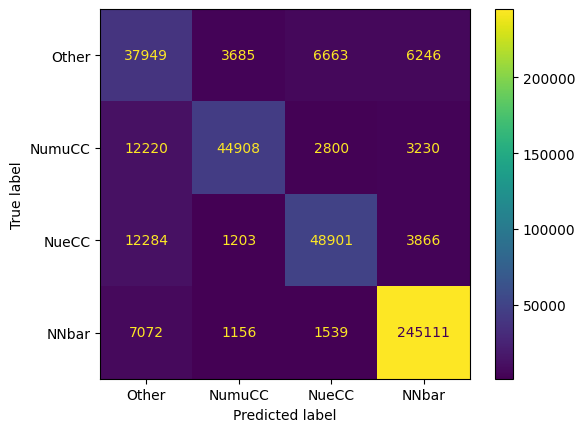

In [27]:
err_mat = confusion_matrix(event_targets, event_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=err_mat, display_labels=event_classes)
disp.plot()

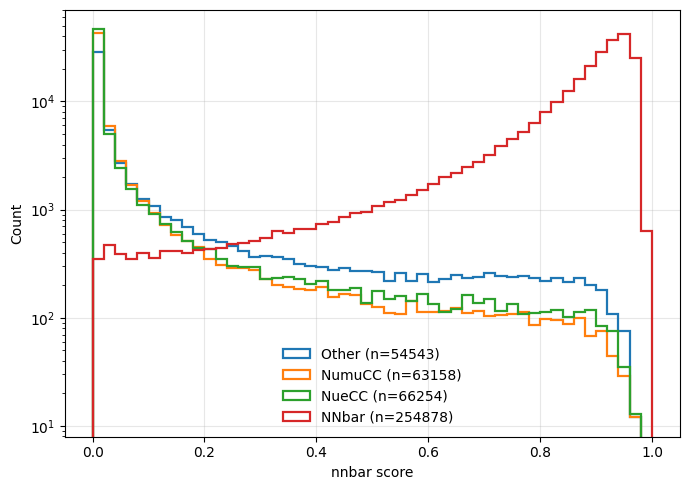

In [28]:

# Create binary true labels for the nnbar class (1 if nnbar, 0 otherwise)
nnbar_class_index = 3 # The index for "nnbar" in the list above
event_targets_np = event_targets.numpy()
event_probabilities_np = event_probabilities.numpy()

# Consistent bins for all plots
bins = np.linspace(0.0, 1.0, 51)  # 50 bins in [0,1]
nnbar_scores = event_probabilities_np[:, nnbar_class_index]
plt.figure(figsize=(7,5))

event_targets_np = np.asarray(event_targets_np)  # ensure ndarray
for class_idx, class_name in enumerate(event_classes):
    mask = (event_targets_np == class_idx)
    scores_c = nnbar_scores[mask]
    if scores_c.size == 0:
        continue
    plt.hist(
        scores_c,
        bins=bins,
        histtype="step",    # outline only (no fill)
        linewidth=1.6,
        label=f"{class_name} (n={scores_c.size})"
    )

plt.yscale("log") 
plt.xlabel("nnbar score")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [29]:
from contextlib import redirect_stdout

#with h5py.File(TESTING_FILE, "r") as f:
#    extra_data = f['extra'][:]  # <-- ADDED: Load the 'extra' dataset
#    trueE_data = f['truesE'][:]  # <-- ADDED: Load the 'truesE' dataset

# --- 2. Find the probability threshold for nnbar at 0.02% FPR ---
target_fpr = 0.00054 # This is 0.02%

# Create binary true labels using the NumPy array
y_true_nnbar = (event_targets_np == nnbar_class_index).astype(int)

# Get the probabilities the model assigned to the nnbar class from the NumPy array
y_prob_nnbar = event_probabilities_np[:, nnbar_class_index]

# Calculate the ROC curve (this function requires NumPy arrays)
fpr, tpr, thresholds = roc_curve(y_true_nnbar, y_prob_nnbar)

# Find the index of the first FPR value >= our target
idx = np.searchsorted(fpr, target_fpr)

# Get the corresponding probability threshold
decision_threshold = thresholds[idx]

print(f"✅ Found decision threshold for 'nnbar' at {target_fpr:.2%} FPR: {decision_threshold:.4f}\n")


# --- 3. Identify and print info for contaminating events ---

print("Searching for contaminating events...")

# Find events using the NumPy arrays
contaminant_indices = np.where(
    (event_targets_np != nnbar_class_index) &
    (y_prob_nnbar >= decision_threshold)
)[0]

with open("contaminant.txt", "w") as f, redirect_stdout(f):
    if len(contaminant_indices) > 0:
        print(f"Found {len(contaminant_indices)} contaminating events.\n---")
        for event_idx in contaminant_indices:
            true_label_idx = event_targets_np[event_idx]
            true_label = event_classes[true_label_idx]
            nnbar_score = event_probabilities_np[event_idx, nnbar_class_index]
            all_scores = event_probabilities_np[event_idx]
#            extra_info = extra_data[event_idx] # <-- ADDED: Get the extra info for this event
#            trueE_info = trueE_data[event_idx] # <-- ADDED: Get the extra info for this event
        
            print(f"Event Index: {event_idx}")
            print(f"  - True Class: '{true_label}' (index {true_label_idx})")
            print(f"  - Misclassified as 'nnbar' with score: {nnbar_score:.4f}")
#            print(f"  - Extra Info: {extra_info}") # <-- recoE, vx, vy, vz     
#            print(f"  - TrueE Info: {trueE_info}") # <-- trueE info                
            print(f"  - All Class Probabilities: {np.round(all_scores, 4)}")
            print("---")
    else:
        print("✅ No contaminating events found at this threshold.")


# Find events using the NumPy arrays
surviving_indices = np.where(
    (event_targets_np == nnbar_class_index) &
    (y_prob_nnbar >= decision_threshold)
)[0]

with open("surviving.txt", "w") as f, redirect_stdout(f):
    if len(surviving_indices) > 0:
        print(f"Found {len(surviving_indices)} surviving events.\n---")
        for event_idx in surviving_indices:
            true_label_idx = event_targets_np[event_idx]
            true_label = event_classes[true_label_idx]
            nnbar_score = event_probabilities_np[event_idx, nnbar_class_index]
            all_scores = event_probabilities_np[event_idx]
#            extra_info = extra_data[event_idx] # <-- ADDED: Get the extra info for this event
#            trueE_info = trueE_data[event_idx] # <-- ADDED: Get the extra info for this event
        
            print(f"Event Index: {event_idx}")
            print(f"  - True Class: '{true_label}' (index {true_label_idx})")
            print(f"  - Misclassified as 'nnbar' with score: {nnbar_score:.4f}")
#            print(f"  - Extra Info: {extra_info}") # <-- recoE, vx, vy, vz     
#            print(f"  - TrueE Info: {trueE_info}") # <-- trueE info                
            print(f"  - All Class Probabilities: {np.round(all_scores, 4)}")
            print("---")
    else:
        print("✅ No surviving events found at this threshold.")

✅ Found decision threshold for 'nnbar' at 0.05% FPR: 0.9507

Searching for contaminating events...
